In [1]:
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Inicializa o servidor do Ollama em segundo plano usando o Python
import subprocess
import time

print("Iniciando o servidor Ollama...")
subprocess.Popen(["ollama", "serve"])
time.sleep(7) # Aguarda 7 segundos para garantir que o servidor subiu na porta local

# 4. Baixa o modelo Phi-3 na GPU estável do Colab
!ollama pull phi3
!pip install ollama z3-solver

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,303 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,183 kB]
Get:13 https://cli.github.com/packages sta

In [2]:
# 1. Garante que nenhum processo antigo do ollama está rodando escondido
!pkill ollama

# 2. Inicializa o servidor em segundo plano direcionando os logs para um arquivo temporário
!ollama serve > /dev/null 2>&1 &

# 3. Aguarda 5 segundos para o servidor abrir as portas de rede na máquina virtual
!sleep 5

# 4. Tenta rodar o pull novamente
!ollama pull phi3

In [3]:
!unzip cenarioLN.zip

Archive:  cenarioLN.zip
   creating: cenarioLN/
  inflating: cenarioLN/cenario_ln_01.csv  
  inflating: cenarioLN/cenario_ln_02.csv  
  inflating: cenarioLN/cenario_ln_03.csv  
  inflating: cenarioLN/cenario_ln_04.csv  
  inflating: cenarioLN/cenario_ln_05.csv  
  inflating: cenarioLN/cenario_ln_06.csv  
  inflating: cenarioLN/cenario_ln_07.csv  
  inflating: cenarioLN/cenario_ln_08.csv  
  inflating: cenarioLN/cenario_ln_09.csv  
  inflating: cenarioLN/cenario_ln_10.csv  


In [4]:
!unzip cenariosZ3.zip

Archive:  cenariosZ3.zip
   creating: cenariosZ3/
  inflating: cenariosZ3/cenarios_gsm_01.csv  
  inflating: cenariosZ3/cenarios_gsm_02.csv  
  inflating: cenariosZ3/cenarios_gsm_03.csv  
  inflating: cenariosZ3/cenarios_gsm_04.csv  
  inflating: cenariosZ3/cenarios_gsm_05.csv  
  inflating: cenariosZ3/cenarios_gsm_06.csv  
  inflating: cenariosZ3/cenarios_gsm_07.csv  
  inflating: cenariosZ3/cenarios_gsm_08.csv  
  inflating: cenariosZ3/cenarios_gsm_09.csv  
  inflating: cenariosZ3/cenarios_gsm_10.csv  


In [5]:
!unzip cenariosphi3.zip

Archive:  cenariosphi3.zip
   creating: cenariosphi3/
  inflating: cenariosphi3/phi3-01.csv  
  inflating: cenariosphi3/phi3-02.csv  
  inflating: cenariosphi3/phi3-03.csv  
  inflating: cenariosphi3/phi3-04.csv  
  inflating: cenariosphi3/phi3-05.csv  
  inflating: cenariosphi3/phi3-06.csv  
  inflating: cenariosphi3/phi3-07.csv  
  inflating: cenariosphi3/phi3-08.csv  
  inflating: cenariosphi3/phi3-09.csv  
  inflating: cenariosphi3/phi3-10.csv  


In [6]:
import csv
import json
import os
import sys
import ollama

def extrair_e_executar_z3(codigo_cru: str, n: int) -> str:
    linhas = codigo_cru.strip().split("\n")
    restricoes_ia = []

    for linha in linhas:
        l_strip = linha.strip()
        if "s.add" in l_strip and "torres" in l_strip and "!=" in l_strip:
            # Remove comentários que a IA possa ter colocado na mesma linha
            if "#" in l_strip:
                l_strip = l_strip.split("#")[0].strip()
            restricoes_ia.append(l_strip)

    infra_codigo = [
        "import z3",
        "s = z3.Solver()",
        f"torres = {{i: z3.Int(f'T{{i}}') for i in range(1, {n} + 1)}}",
        "for t in torres.values():",
        "    s.add(t >= 1, t <= 3)",
    ]

    infra_codigo.extend(restricoes_ia)
    infra_codigo.extend([
        "if s.check() == z3.sat:",
        "    RESULTADO_PROVER = 'SAT'",
        "else:",
        "    RESULTADO_PROVER = 'UNSAT'"
    ])

    codigo_final = "\n".join(infra_codigo)
    escopo_local = {}

    try:
        exec(codigo_final, {}, escopo_local)
        resultado = escopo_local.get("RESULTADO_PROVER", "ERRO")
        return str(resultado).strip().upper()
    except Exception as e:
        print("\n" + "═" * 60)
        print("[DEBUG] O CÓDIGO FINAL MONSTADO FALHOU:")
        print("═" * 60)
        print(codigo_final)
        print("═" * 60)
        print(f"MOTIVO DA FALHA: {e}")
        print("═" * 60 + "\n")
        return "ERRO"

def analisar_lotes_neuro_simbolicos():
    pasta_origem = "cenariosZ3"
    pasta_destino = "cenarios_z3_phi3"
    modelo_llm = "phi3"

    os.makedirs(pasta_destino, exist_ok=True)
    total_arquivos = 10

    for i_arquivo in range(1, total_arquivos + 1):
        arq_entrada = f"cenarios_gsm_{i_arquivo:02d}.csv"
        arq_saida = f"phi3-code-{i_arquivo:02d}.csv"

        caminho_entrada = os.path.join(pasta_origem, arq_entrada)
        caminho_saida = os.path.join(pasta_destino, arq_saida)

        if not os.path.exists(caminho_entrada):
            print(f"ERRO: Arquivo {arq_entrada} não encontrado. Pulando...")
            continue

        print(f"\n" + "=" * 60)
        print(f"LENDO: {arq_entrada}")
        print(f"=" * 60)

        resumos_rodadas = []
        acertos_cod_z3 = 0
        total_lote = 0

        with open(caminho_entrada, mode='r', encoding='utf-8') as f_in:
            leitor = csv.DictReader(f_in)

            for table_row in leitor:
                total_lote += 1
                rodada = int(table_row["rodada"])
                n = int(table_row["qtd_torres"])
                qtd_conexoes = int(table_row["qtd_conexoes"])
                gabarito_z3 = table_row["resultado_z3"]
                V = [tuple(par) for par in json.loads(table_row["conexoes"])]

                prompt_gerar_z3 = (
"Você é um tradutor automático de grafos para restrições lógicas do solver Z3.\n\n"
f"DADOS DO GRAFO:\n"
f"- Quantidade de Torres: {n}\n"
f"- Lista de Arestas (Conexões): {V}\n\n"
"Sua única tarefa é gerar uma linha de código para cada par (A, B) da lista acima, seguindo estritamente este formato:\n"
"s.add(torres[A] != torres[B])\n\n"
"REGRAS CRÍTICAS:\n"
"1. Escreva APENAS as linhas contendo 's.add(...)'. Não adicione explicações, saudações ou blocos de código markdown.\n"
"2. Não tente criar o solver, não faça os imports e não escreva o 'if' final. O sistema cuidará disso.\n"
"3. Não pule nenhuma conexão e não use reticências (...)."
                )

                try:
                    resp_cod = ollama.chat(
                        model=modelo_llm,
                        messages=[{'role': 'user', 'content': prompt_gerar_z3}],
                        options={'temperature': 0.0}
                    )
                    codigo_gerado = resp_cod['message']['content']

                    pred_cod_z3 = extrair_e_executar_z3(codigo_gerado, n)
                    status_cod = "CORRETO" if pred_cod_z3 == gabarito_z3 else "ERRADO"

                    if status_cod == "CORRETO":
                        acertos_cod_z3 += 1

                    print(f"--> Linha {rodada:02d} | Torres:{n:02d} | Conexões:{qtd_conexoes:02d} | Gabarito Z3={gabarito_z3} | Resposta IA Código={pred_cod_z3} ({status_cod})")

                    resumos_rodadas.append([
                        rodada, n, qtd_conexoes, gabarito_z3, pred_cod_z3, status_cod
                    ])

                except Exception as e:
                    print(f"Erro crítico na linha {rodada}: {e}")
                    resumos_rodadas.append([rodada, n, qtd_conexoes, gabarito_z3, "ERRO", "ERRADO"])

        with open(caminho_saida, mode='w', newline='', encoding='utf-8') as f_out:
            escritor = csv.writer(f_out)
            escritor.writerow(["rodada", "qtd_torres", "qtd_conexoes", "resultado_z3", "phi3_cod_z3", "status_cod_z3"])
            escritor.writerows(resumos_rodadas)

        taxa_cod = (acertos_cod_z3 * 100.0) / total_lote
        print(f"\n[LIDO] {i_arquivo:02d} | % Acerto LLM-Z3: {taxa_cod:.2f}%")

    print("\nDEBUG: Processamento isolado concluído com sucesso!")


if __name__ == "__main__":
    analisar_lotes_neuro_simbolicos()


LENDO: cenarios_gsm_01.csv
--> Linha 01 | Torres:08 | Conexões:08 | Gabarito Z3=SAT | Resposta IA Código=SAT (CORRETO)

════════════════════════════════════════════════════════════
[DEBUG] O CÓDIGO FINAL MONSTADO FALHOU:
════════════════════════════════════════════════════════════
import z3
s = z3.Solver()
torres = {i: z3.Int(f'T{i}') for i in range(1, 5 + 1)}
for t in torres.values():
    s.add(t >= 1, t <= 3)
s.add(torres[1] != torres[2])
s.add(torres[2] != torres[3])
sde s.add(torres[3] != torres[4])
s.add(torres[4] != torres[5])
s.add(torres[2] != torres[4])
if s.check() == z3.sat:
    RESULTADO_PROVER = 'SAT'
else:
    RESULTADO_PROVER = 'UNSAT'
════════════════════════════════════════════════════════════
MOTIVO DA FALHA: invalid syntax (<string>, line 8)
════════════════════════════════════════════════════════════

--> Linha 02 | Torres:05 | Conexões:05 | Gabarito Z3=SAT | Resposta IA Código=ERRO (ERRADO)
--> Linha 03 | Torres:20 | Conexões:38 | Gabarito Z3=SAT | Resposta IA Cód

ANÁLISE COMPARATIVA: LLM-Z3 (TUPLAS) VS. LLM Linguagem Natural VS. LLM-Z3 (TRADUÇÃO)
Total de cenários avaliados: 276
1. Código LLM-Z3 (Tuplas) | Acertos: 173 | Taxa: 62.68%
2. LLM Linguagem Natural    | Acertos: 77 | Taxa: 27.90%
3. LLM-Z3 (TRADUÇÃO) | Acertos: 175 | Taxa: 63.41%

DEBUG: Dados comparativos globais exportados para 'acerto-llm-tuplascoord.csv'


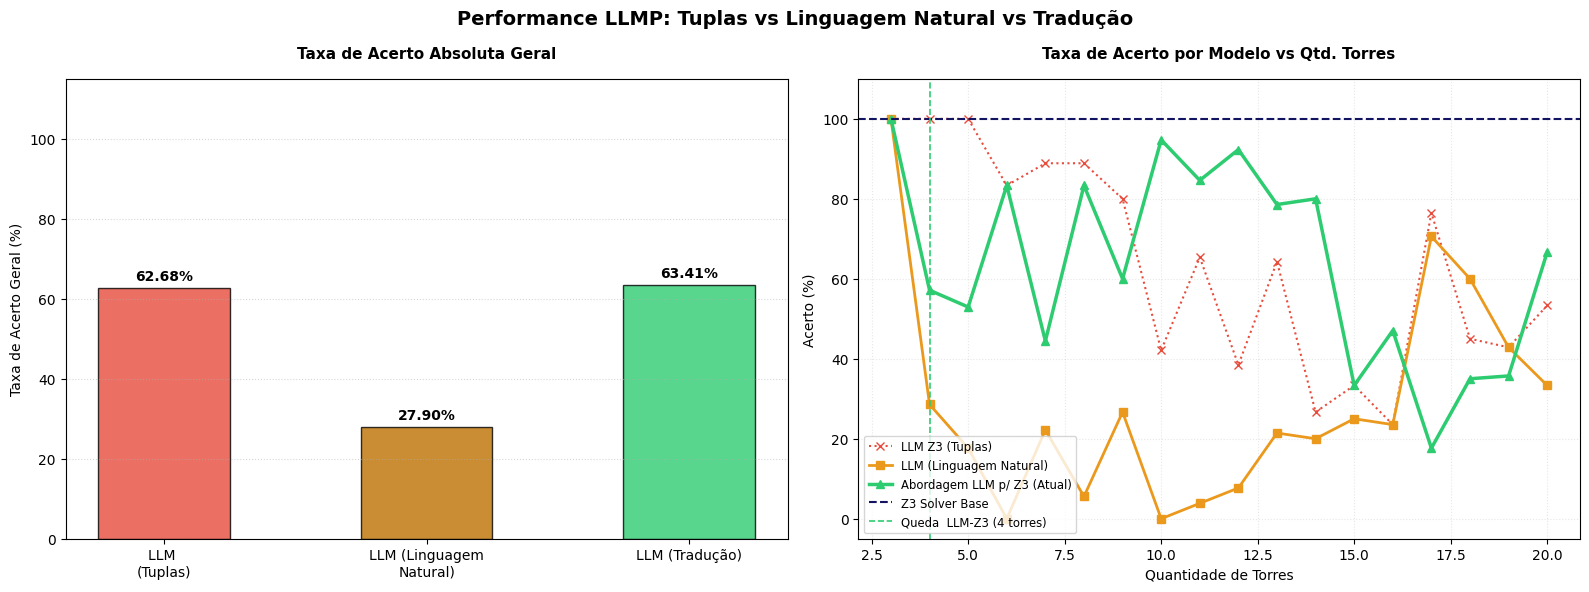

In [8]:
import os
import glob
import sys
import pandas as pd
import matplotlib.pyplot as plt

def carregar_e_mesclar_dados(pasta_antiga: str, pasta_nova: str) -> pd.DataFrame:
    """Busca os arquivos antigos e novos e unifica tudo em um único DataFrame por rodada."""
    arquivos_antigos = glob.glob(os.path.join(pasta_antiga, "phi3-*.csv"))
    arquivos_novos = glob.glob(os.path.join(pasta_nova, "phi3-*.csv"))

    if not arquivos_novos:
        print(f"ERRO: Nenhum arquivo encontrado em '{pasta_nova}'. Rode o teste corrigido do Phi-3 primeiro!")
        sys.exit(1)

    df_novo = pd.concat([pd.read_csv(arq) for arq in arquivos_novos], ignore_index=True)
    if arquivos_antigos:
        df_antigo = pd.concat([pd.read_csv(arq) for arq in arquivos_antigos], ignore_index=True)

        cols_antigas = [col for col in ['rodada', 'qtd_torres', 'status_estruturado', 'status_natural'] if col in df_antigo.columns]
        df_total = pd.merge(df_novo, df_antigo[cols_antigas], on=['rodada', 'qtd_torres'], how='left')
        return df_total
    else:
        print("AVISO: Pasta antiga não encontrada ou vazia. Simulando a abordagem anterior que quebrou como 0%.")
        df_novo['status_estruturado'] = 'ERRADO'
        df_novo['status_natural'] = 'ERRADO'
        return df_novo


def main():
    pasta_antiga = "cenariosphi3"
    pasta_nova = "cenarios_z3_phi3"

    df_total = carregar_e_mesclar_dados(pasta_antiga, pasta_nova)

    # =======================================================
    #               MÉTRICAS GERAIS (SOMA TOTAL)
    # =======================================================

    total_testes = len(df_total)
    acertos_ant_cod = len(df_total[df_total['status_estruturado']=='CORRETO']) if 'status_estruturado' in df_total.columns else 0
    acertos_nat = len(df_total[df_total['status_natural']=='CORRETO']) if 'status_natural' in df_total.columns else 0
    acertos_neuro = len(df_total[df_total['status_cod_z3']=='CORRETO'])

    taxa_ant_geral = (acertos_ant_cod / total_testes) * 100
    taxa_nat_geral = (acertos_nat / total_testes) * 100
    taxa_neuro_geral = (acertos_neuro / total_testes) * 100

    print("=" * 70)
    print("ANÁLISE COMPARATIVA: LLM-Z3 (TUPLAS) VS. LLM Linguagem Natural VS. LLM-Z3 (TRADUÇÃO)")
    print("=" * 70)
    print(f"Total de cenários avaliados: {total_testes}")
    print(f"1. Código LLM-Z3 (Tuplas) | Acertos: {acertos_ant_cod} | Taxa: {taxa_ant_geral:.2f}%")
    print(f"2. LLM Linguagem Natural    | Acertos: {acertos_nat} | Taxa: {taxa_nat_geral:.2f}%")
    print(f"3. LLM-Z3 (TRADUÇÃO) | Acertos: {acertos_neuro} | Taxa: {taxa_neuro_geral:.2f}%")
    print("=" * 70)

    # =======================================================
    #        PROCESSAMENTO DOS DADOS POR QUANTIDADE DE TORRES
    # =======================================================

    df_ant = df_total.groupby('qtd_torres')['status_estruturado'].apply(lambda x: (x=='CORRETO').mean()*100)
    df_nat = df_total.groupby('qtd_torres')['status_natural'].apply(lambda x: (x=='CORRETO').mean()*100)
    df_neu = df_total.groupby('qtd_torres')['status_cod_z3'].apply(lambda x: (x=='CORRETO').mean()*100)

    # DataFrame unificado de taxas
    df_agrupado = pd.DataFrame({
        'Taxa_Anterior_Codigo_%': df_ant,
        'Taxa_Natural_%': df_nat,
        'Taxa_Neuro_Simbolica_%': df_neu
    }).fillna(0.0).round(2)

    # Exportação do novo DataFrame consolidado para CSV
    df_agrupado.to_csv('acerto-llm-tuplascoord.csv', sep=';', encoding='utf-8')
    print("\nDEBUG: Dados comparativos globais exportados para 'acerto-llm-tuplascoord.csv'")

    # Extração de Pontos Críticos de Queda
    ponto_queda_neuro = None
    for torres in df_agrupado.index:
        if ponto_queda_neuro is None and df_agrupado.loc[torres, 'Taxa_Neuro_Simbolica_%'] < 100.0:
            ponto_queda_neuro = torres
            break

    # =======================================================
    #          PLOTAGEM DOS GRÁFICOS (MATPLOTLIB)
    # =======================================================

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Performance LLMP: Tuplas vs Linguagem Natural vs Tradução", fontsize=14, fontweight='semibold')

    # --- Gráfico 1: Barras Comparativas Totais ---
    categorias = ['LLM \n(Tuplas)', 'LLM (Linguagem\nNatural)', 'LLM (Tradução)']
    valores = [taxa_ant_geral, taxa_nat_geral, taxa_neuro_geral]
    cores_barras = ["#e74c3c", "#bd7100", "#2ecc71"] # Vermelho (Falha), Laranja (Médio), Verde (Sucesso)

    barras = ax1.bar(categorias, valores, color=cores_barras, width=0.5, edgecolor='black', alpha=0.8)
    ax1.set_title("Taxa de Acerto Absoluta Geral", fontsize=11, fontweight='bold', pad=15)
    ax1.set_ylabel("Taxa de Acerto Geral (%)", fontsize=10)
    ax1.set_ylim(0, 115)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)

    for barra in barras:
        height = barra.get_height()
        ax1.annotate(f'{height:.2f}%',
                     xy=(barra.get_x() + barra.get_width() / 2, height),
                     xytext=(0, 4),
                     textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold')

    # --- Gráfico 2: Curvas de Degradação Combinadas ---
    # Linha do Modelo Código Anterior (Se houver dados)
    ax2.plot(df_agrupado.index, df_agrupado['Taxa_Anterior_Codigo_%'], marker='x',
             linewidth=1.5, color="#e74c3c", linestyle=':', label='LLM Z3 (Tuplas)')

    ax2.plot(df_agrupado.index, df_agrupado['Taxa_Natural_%'], marker='s',
             linewidth=2.0, color="#eb991d", label='LLM (Linguagem Natural)')

    ax2.plot(df_agrupado.index, df_agrupado['Taxa_Neuro_Simbolica_%'], marker='^',
             linewidth=2.5, color="#2ecc71", label='Abordagem LLM p/ Z3 (Atual)')

    ax2.axhline(y=100, color="#131461", linestyle='--', linewidth=1.5, label='Z3 Solver Base')

    # Identifica visualmente onde o novo modelo começa a falhar na escala de complexidade
    if ponto_queda_neuro is not None:
        ax2.axvline(x=ponto_queda_neuro, color="#2ecc71", linestyle='--',
                    linewidth=1.2, label=f'Queda  LLM-Z3 ({ponto_queda_neuro} torres)')

    ax2.set_title("Taxa de Acerto por Modelo vs Qtd. Torres", fontsize=11, fontweight='bold', pad=15)
    ax2.set_xlabel("Quantidade de Torres", fontsize=10)
    ax2.set_ylabel("Acerto (%)", fontsize=10)
    ax2.set_ylim(-5, 110)
    ax2.grid(True, linestyle=':', alpha=0.3)
    ax2.legend(loc='lower left', fontsize='small')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()